In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
file_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/data/lion_window_summaries_with_clusters.csv"
df_summary = pd.read_csv(file_path)
df_summary.head()


,distance_mean,dx_var,dy_var,dz_var,turn_var,Cluster
0,0.000039,2.165023e-09,3.644655e-09,2.898543e-09,2.618362,3
1,0.000033,1.982146e-09,3.605593e-09,2.235792e-09,2.522717,3
2,0.000021,1.017195e-09,1.406908e-09,1.506095e-09,2.753134,3
3,0.000022,1.015387e-09,1.403744e-09,1.504438e-09,2.755821,1
4,0.000020,1.003975e-09,1.398375e-09,1.473401e-09,2.359527,1


In [12]:
X = df_summary.drop(columns=["Cluster"])
X.head()

,distance_mean,dx_var,dy_var,dz_var,turn_var
0,0.000039,2.165023e-09,3.644655e-09,2.898543e-09,2.618362
1,0.000033,1.982146e-09,3.605593e-09,2.235792e-09,2.522717
2,0.000021,1.017195e-09,1.406908e-09,1.506095e-09,2.753134
3,0.000022,1.015387e-09,1.403744e-09,1.504438e-09,2.755821
4,0.000020,1.003975e-09,1.398375e-09,1.473401e-09,2.359527


In [11]:
y = df_summary["Cluster"]
y.head()


,Cluster
0,3
1,3
2,3
3,1
4,1


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12761, 5)
(3191, 5)
(12761,)
(3191,)


In [18]:
#learning
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,criterion='gini',max_features='sqrt',max_depth=None,min_samples_split=2,random_state=7)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=7)

In [19]:
#testing
y_pred = rf.predict(X_test)

In [26]:
#evaluation
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(f"accuracy_scores : {accuracy_score(y_test,y_pred)}\n")

print(f"confustion matrix :\n {confusion_matrix(y_test,y_pred)}\n")

print(f"classification report : \n{classification_report(y_test,y_pred)}")

accuracy_scores : 0.6515198997179568

confustion matrix :
 [[628  49 115 131]
 [ 58 475 164  88]
 [103 108 560  13]
 [151 113  19 416]]

classification report : 
              precision    recall  f1-score   support

           0       0.67      0.68      0.67       923
           1       0.64      0.61      0.62       785
           2       0.65      0.71      0.68       784
           3       0.64      0.60      0.62       699

    accuracy                           0.65      3191
   macro avg       0.65      0.65      0.65      3191
weighted avg       0.65      0.65      0.65      3191



In [28]:
#feature importance analysis
importances = rf.feature_importances_
feature_name = X.columns
feature_importance = pd.Series(importances, index=feature_name).sort_values(ascending=False)
print(feature_importance)

dz_var           0.206739
dx_var           0.206041
dy_var           0.205256
distance_mean    0.200638
turn_var         0.181326
dtype: float64


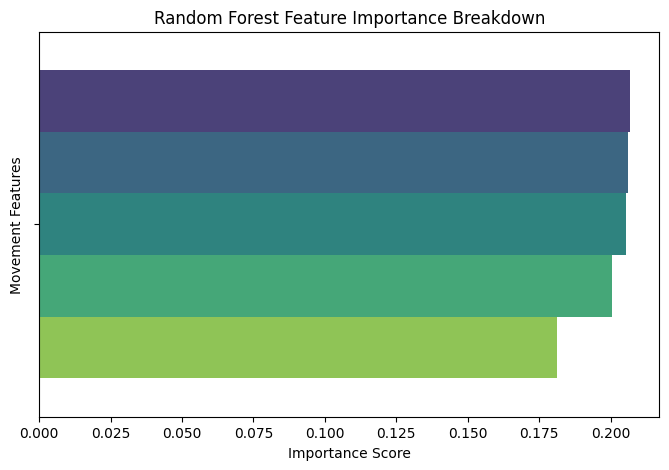

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, hue=feature_importance.index, palette='viridis', legend=False)
plt.title("Random Forest Feature Importance Breakdown")
plt.xlabel("Importance Score")
plt.ylabel("Movement Features")
graph_save_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/images/random_forest_feature_importances_v1.png"
plt.savefig(graph_save_path, bbox_inches='tight', dpi=300)
plt.show()

In [38]:
#model refinement using GridSearch
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=parameter_grid, cv=5,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=7), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=2)

In [39]:
print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Tuned Accuracy Score: {accuracy_score(y_test, y_pred_tuned)}\n")
print("Tuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Accuracy Score: 0.6477593230962081

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.68      0.67       923
           1       0.64      0.60      0.62       785
           2       0.64      0.71      0.67       784
           3       0.63      0.59      0.61       699

    accuracy                           0.65      3191
   macro avg       0.65      0.64      0.64      3191
weighted avg       0.65      0.65      0.65      3191



In [41]:
import joblib
joblib.dump(best_rf, "/content/drive/MyDrive/Lion-Biologging-SoS'26/models/lion_behavior_rf_model.pkl")

["/content/drive/MyDrive/Lion-Biologging-SoS'26/models/lion_behavior_rf_model.pkl"]